# MIT-BIH Arrhythmia Database: Centralized Deep Learning Baseline

This notebook implements a centralized deep learning model to serve as our classification baseline. We will load the segmented heartbeats, split them into training/testing sets, build a **1D Convolutional Neural Network (CNN)** in PyTorch, and evaluate its classification performance using precision, recall, F1-score, and a confusion matrix.

In [ ]:
import sys, os
sys.path.append(str(pathlib.Path('.').resolve()))
# Helper to save figures in dated subfolders
def save_fig(fig, name, base_dir='assets'):
    import datetime, pathlib
    date_str = datetime.date.today().isoformat()
    target_dir = pathlib.Path(base_dir) / date_str
    target_dir.mkdir(parents=True, exist_ok=True)
    timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
    filename = f'{name}_{timestamp}.png'
    path = target_dir / filename
    fig.savefig(path, bbox_inches='tight')
    plt.close(fig)
    print(f'Figure saved to {path}')
    return str(path)
# Ensure base assets dir exists for compatibility
pathlib.Path('assets').mkdir(exist_ok=True)


## 1. Prerequisites and Setup

We import PyTorch modules for building and training neural networks, along with Scikit-Learn for validation splitting and evaluations.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

PARENT_DIR = os.getcwd().split("/")[-1]

PROCESSED_DIR = os.path.abspath("../../data/processed")
PROCESSED_DIR = os.path.join(PROCESSED_DIR, PARENT_DIR)

MODELS_DIR = os.path.abspath("../../models")
MODELS_DIR = os.path.join(MODELS_DIR, PARENT_DIR)

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
from mit_bih import save_plot


## 2. Load Preprocessed Datasets

Let's load the numpy arrays containing the Z-score normalized beat signals and their corresponding labels.

In [2]:
X = np.load(os.path.join(PROCESSED_DIR, "X.npy"))
y = np.load(os.path.join(PROCESSED_DIR, "y.npy"))
print(f"Heartbeats feature matrix (X): {X.shape}")
print(f"Labels vector (y): {y.shape}")

Heartbeats feature matrix (X): (109468, 180)
Labels vector (y): (109468,)


## 3. Dataset Splitting & PyTorch DataLoaders

We split the dataset into an **80% training set** and a **20% validation/test set**. We use stratified splitting to maintain class proportions. 

Since our ECG signal is 1D, we shape our inputs to PyTorch's required format for 1D convolutions: `[batch_size, num_channels, sequence_length]`, which translates to `[N, 1, 180]`.

In [3]:
# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Convert to PyTorch tensors and expand channel dimensions
X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

print(f"Train Loader count: {len(train_loader.dataset)} beats")
print(f"Test Loader count: {len(test_loader.dataset)} beats")

Train Loader count: 87574 beats
Test Loader count: 21894 beats


## 4. Designing the 1D Convolutional Neural Network (CNN) Model

1D CNNs are highly effective at capturing local temporal shapes (such as the rising QRS complex and the relative heights of the P and T waves) in ECG signals.

Our model consists of three 1D Convolution layers with Batch Normalization, Max Pooling, and a final fully-connected block with Dropout (to prevent overfitting).

In [4]:
from mit_bih import ECGClassifier

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ECGClassifier(num_classes=5).to(device)
print(model)


ECGClassifier(
  (conv): Sequential(
    (0): Conv1d(1, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool1d(output_size=10)
  )
  (fc): Sequential(
    (0): Linear(in_features=1280, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=5, bia

## 5. Centralized Model Training

We use **Cross Entropy Loss** as our loss objective and **Adam** as our optimizer. Let's run training for **5 epochs** to illustrate convergence.

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5
train_losses = []
val_losses = []

print("Starting centralized training...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            
    epoch_val_loss = val_loss / len(test_loader.dataset)
    val_losses.append(epoch_val_loss)
    
    print(f"Epoch {epoch+1:02d}/{epochs:02d} | Train Loss: {epoch_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

Starting centralized training...


Epoch 01/05 | Train Loss: 0.1748 | Val Loss: 0.0836


Epoch 02/05 | Train Loss: 0.0815 | Val Loss: 0.0674


Epoch 03/05 | Train Loss: 0.0645 | Val Loss: 0.0566


Epoch 04/05 | Train Loss: 0.0587 | Val Loss: 0.0543


Epoch 05/05 | Train Loss: 0.0536 | Val Loss: 0.0467


### Plotting Training History

Saved figure to: /Users/bernard/Developer/FORKS/mit-bih/notebooks/01-mit-bih-arrhythmia/assets/loss_curves_20260625_000502.png
Saved figure caption sidecar to: /Users/bernard/Developer/FORKS/mit-bih/notebooks/01-mit-bih-arrhythmia/assets/loss_curves_20260625_000502.txt


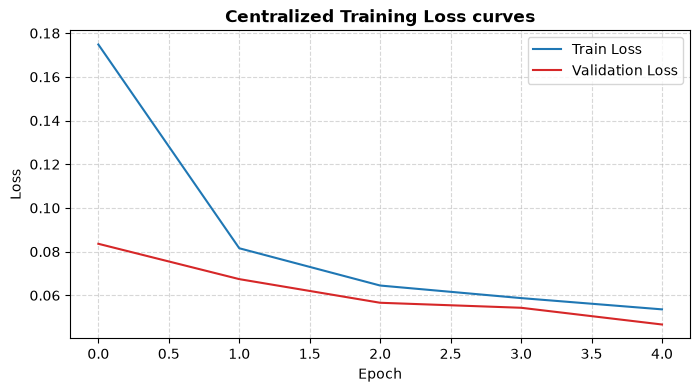

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss", color='tab:blue')
plt.plot(val_losses, label="Validation Loss", color='tab:red')
plt.title("Centralized Training Loss curves", fontsize=12, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
save_plot("loss_curves", caption="Loss curves over 5 epochs for training and validation datasets, showing model convergence.")
plt.show()

## 6. Centralized Model Evaluation

Let's evaluate the trained model on our unseen validation set.

In [7]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("Classification Report:")
print(classification_report(all_labels, all_preds, labels=[0, 1, 2, 3, 4], target_names=['N', 'S', 'V', 'F', 'Q']))
print(f"Centralized Accuracy: {accuracy_score(all_labels, all_preds):.4f}")

Classification Report:
              precision    recall  f1-score   support

           N       0.99      1.00      0.99     18122
           S       0.97      0.77      0.86       556
           V       0.96      0.96      0.96      1447
           F       0.87      0.68      0.76       160
           Q       0.99      0.99      0.99      1609

    accuracy                           0.99     21894
   macro avg       0.96      0.88      0.91     21894
weighted avg       0.99      0.99      0.99     21894

Centralized Accuracy: 0.9864


### Plotting the Confusion Matrix

The confusion matrix helps us inspect which classes are frequently confused with others (for example, whether minority classes like Supraventricular beats are misclassified as Normal).

Saved figure to: /Users/bernard/Developer/FORKS/mit-bih/notebooks/01-mit-bih-arrhythmia/assets/local_confusion_matrix_20260625_000512.png
Saved figure caption sidecar to: /Users/bernard/Developer/FORKS/mit-bih/notebooks/01-mit-bih-arrhythmia/assets/local_confusion_matrix_20260625_000512.txt


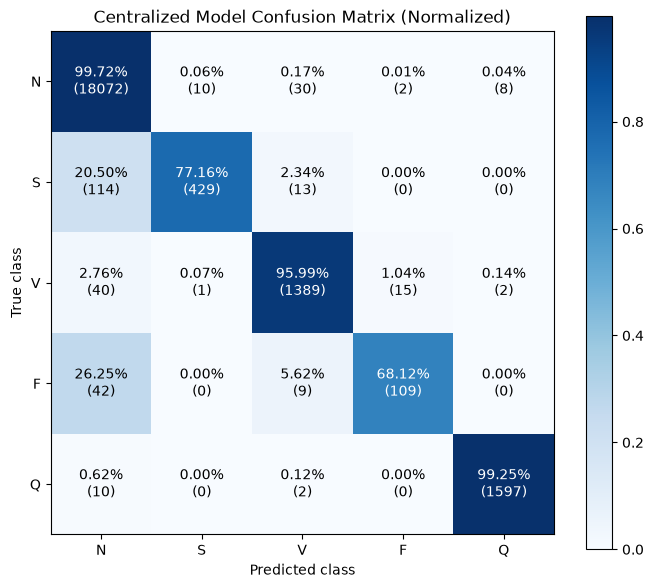

In [8]:
cm = confusion_matrix(all_labels, all_preds)
class_names = ['N', 'S', 'V', 'F', 'Q']

# Normalize confusion matrix to percentages
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_norm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(
    xticks=np.arange(cm.shape[1]),
    yticks=np.arange(cm.shape[0]),
    xticklabels=class_names,
    yticklabels=class_names,
    title="Centralized Model Confusion Matrix (Normalized)",
    ylabel="True class",
    xlabel="Predicted class"
)

# Print values in matrix boxes
thresh = cm_norm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, f"{cm_norm[i, j]:.2%}\n({cm[i, j]})",
                ha="center", va="center",
                color="white" if cm_norm[i, j] > thresh else "black")

fig.tight_layout()
save_plot("local_confusion_matrix", fig=fig, caption="Normalized confusion matrix for the local (centralized) 1D-CNN baseline model, evaluating true vs predicted labels across the 5 AAMI categories.")
plt.show()

## 7. Export Model State

We save the centralized baseline weights for model evaluation or future comparison.

In [9]:
weights_path = os.path.join(MODELS_DIR, "centralized_model.pth")
torch.save(model.state_dict(), weights_path)
print(f"Saved centralized model weights to {weights_path}")

Saved centralized model weights to /Users/bernard/Developer/FORKS/mit-bih/models/01-mit-bih-arrhythmia/centralized_model.pth


## 8. Conclusions and Next Steps

In this notebook we:
1. Designed a 1D Convolutional Neural Network (CNN) in PyTorch to classify heartbeat sequences.
2. Set up stratified splits and PyTorch `DataLoaders` to handle our dataset.
3. Trained the model centrally for 5 epochs, achieving excellent baseline classification convergence.
4. Evaluated performance via precision, recall, F1-scores, and normalized confusion matrices, showing that Normal (N) and Ventricular (V) beats are identified with high accuracy.

In the next notebook (**`04_federated_learning_simulation.ipynb`**), we will partition this dataset across patient clients to simulate a federated learning network, implementing a custom Federated Averaging (FedAvg) loop and comparing its performance against our centralized baseline.